# Hard Istance Max Cut with different annealing methods

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule

## Initialization of the target Hamiltonian

#### Hyperapameters

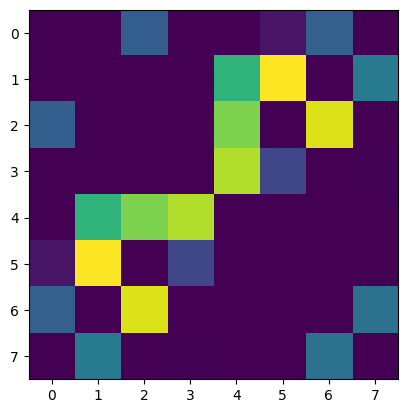

In [2]:
#### create istances on networkx
nqubits = 8

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=8)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = nx.to_numpy_array(graph_instance)  # unweighted adjacency matrix

plt.imshow(jij)
plt.show()

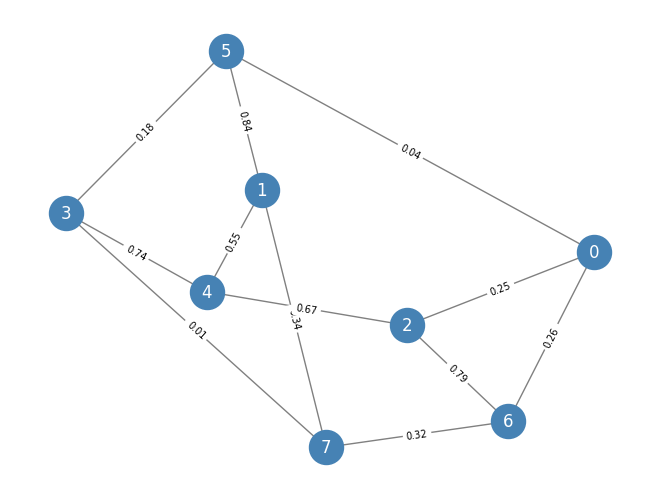

In [3]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [4]:
nqubits=jij.shape[0]

target_hamiltonian=get_longitudinal_hamiltonian(jij)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)



#### Analysis of the spectrum of the target hamiltonian

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


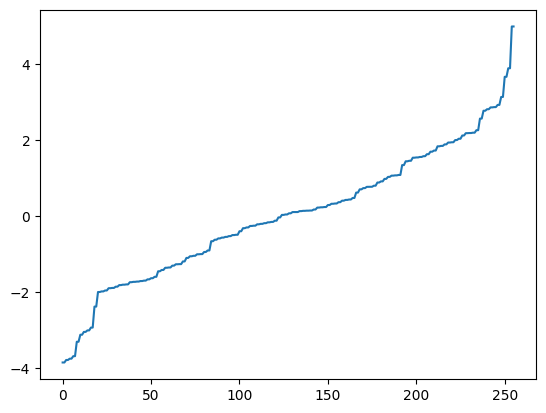

(-3.8624858679944882+0j) (-3.7969717693733216+0j) [1 1 1 1 0 0 0 0] [1 1 1 1 0 0 0 1]


In [5]:
values=target_hamiltonian.diagonal()

spectrum_target_hamiltonian=np.sort(values)
eigenstates_target_hamiltonian=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian)
plt.show()

print(spectrum_target_hamiltonian[0],spectrum_target_hamiltonian[2],eigenstates_target_hamiltonian[0],eigenstates_target_hamiltonian[2])

#### Time evolution

In [6]:
from scipy.sparse.linalg import eigsh,expm_multiply
# initialize the state
_,psi=eigsh(driver_hamiltonian,which='SA',k=1)
psi_init=psi[:,0]

# nlevels and time evolution
nlevels=4
tau=10
time_steps=int(20*tau)
time=np.linspace(0,tau,time_steps)
delta_t=time[1]-time[0]

# initialization
spectrum=np.zeros((time_steps,nlevels))
eigenstates_history=np.zeros((time_steps,psi.shape[0],nlevels))
energy=np.zeros(time_steps)

psi=psi_init
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,eigenstates=eigsh(hamiltonian_t,which='SA',k=nlevels)
    spectrum[i]=np.sort(spectrum_t)
    eigenstates_history[i]=eigenstates
    energy[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    
    

/tmp/ipykernel_33760/798822088.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenstates_history[i]=eigenstates
/tmp/ipykernel_33760/798822088.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t.dot(psi))


Check the results

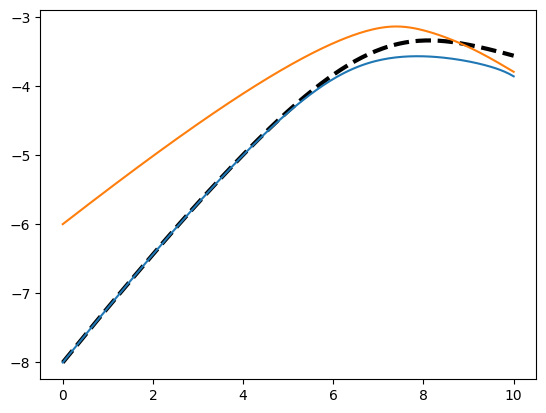

In [7]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
    if i%2==0:
        plt.plot(time,spectrum[:,i])

plt.show()

## Optimal Control Method

##### Get Hyperparameters

In [8]:
number_parameters=5
type='F-CRAB'

In [9]:
from scipy.optimize import minimize

model=SchedulerModel(initial_state=psi_init,target_hamiltonian=target_hamiltonian,initial_hamiltonian=driver_hamiltonian,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

-3.5966957064181764
-3.6087696223328787
-3.6344158288905417
-3.637714648081871
-3.643294961774775
-3.665784265071338
-3.676325966085974
-3.6947809292616594
-3.7031046060612796
-3.706569068777448
-3.7070770871343672
-3.708258497725228
-3.7089825608092566
-3.70972399943824
-3.710394973733919
-3.7108812941899902
-3.711841580519388
-3.7137265394944263
-3.718382066870311
-3.7248753498787677
-3.7274075532126103
-3.728320572086159
-3.729195695624639
-3.7301370846172124
-3.730481596646378
-3.730987410548163
-3.731431150623425
-3.7323093774871303
-3.733398594750153
-3.7340918662804974
-3.7344295815150375
-3.734616801275353
-3.7350241116093335
-3.73558138594958
-3.7365642421240968
-3.7377192392882934
-3.738608969379371
-3.7404729640112038
-3.7438632415324373
-3.7441548277351524
-3.7460873169781075
-3.746850989652825
-3.747518398563397
-3.747900082088567
-3.7482179520740986
-3.748502346794691
-3.7488546818958373
-3.7493445667925185
-3.7500000578088573
-3.7503178278588996
-3.750489739247488
-3.750

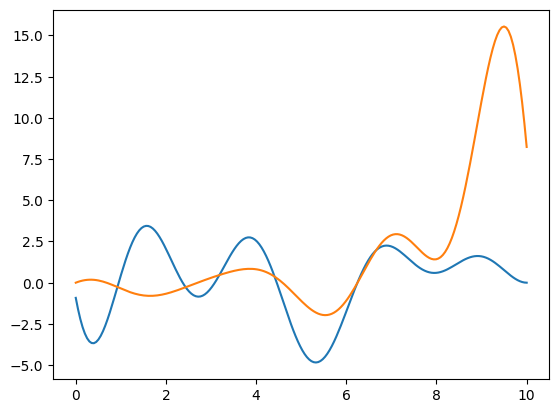

In [ ]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

_, psi = eigsh(h_driver[0]*driver_hamiltonian.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)


plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()
psi = psi_init.copy()
for i in range(time_steps):
    hamiltonian_t = h_driver[i] * driver_hamiltonian + h_target[i] * target_hamiltonian
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    energy_optimal[i] = (psi.conj().dot(hamiltonian_t.dot(psi))).real
    psi_optimal_history[i] = psi

# linear
nlevels=5
spectrum=np.zeros((time_steps,nlevels))
psi = psi_init.copy()
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) *h_driver[0]*driver_hamiltonian + (t / tau) *h_target[-1]*target_hamiltonian
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    spectrum[i]=spectrum_t
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    energy_linear[i] = (psi.conj().dot(hamiltonian_t.dot(psi))).real
    psi_linear_history[i] = psi



# ── probabilities: |<psi_linear(t) | psi_optimal(t)>|^2 ──────────────────────
overlap_vs_time = np.abs(
    np.einsum('ti,ti->t', psi_linear_history.conj(), psi_optimal_history)
) ** 2

##### Results

In [36]:
_, psi = eigsh(driver_hamiltonian.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)

# sanity check
e_init = (psi_init.conj().dot(driver_hamiltonian.dot(psi_init))).real
print(f'<psi_init|H_driver|psi_init> = {e_init:.6f}')

<psi_init|H_driver|psi_init> = -8.000000


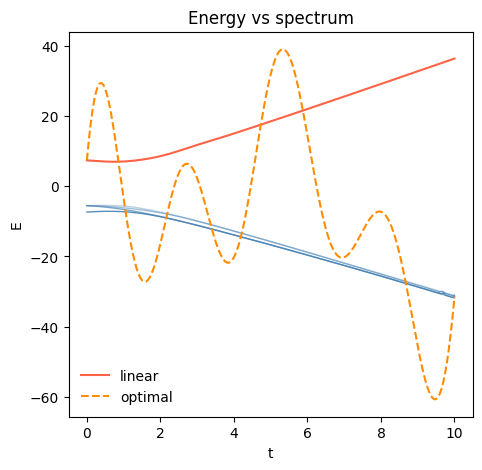

In [37]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, hspace=0.3, wspace=0.3)

# ── 1. Energy vs time + spectrum ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

# spectrum levels
for lvl in range(nlevels):
    ax1.plot(time, spectrum[:, lvl], color='steelblue', alpha=0.9 - 0.2 * lvl, linewidth=1)

# shade the gap
#ax1.fill_between(time, spectrum[:, 0], spectrum[:, 1], alpha=0.15, color='steelblue', label='gap')

# energies
ax1.plot(time, energy_linear,  label='linear',  color='tomato',      linewidth=1.5)
ax1.plot(time, energy_optimal, label='optimal', color='darkorange',  linewidth=1.5, linestyle='--')

ax1.set_xlabel('t')
ax1.set_ylabel('E')
ax1.set_title('Energy vs spectrum')

ax1.legend(frameon=False)


In [ ]:
# final energy of both schedules vs true GS of target
evals_target, _ = eigsh(target_hamiltonian.astype(complex), which='SA', k=4)
evals_target = np.sort(evals_target)

print(f'GS energy target:         {evals_target[0]:.6f}')
print(f'1st excited target:       {evals_target[1]:.6f}')
print(f'Final energy linear:      {energy_linear[-1]:.6f}')
print(f'Final energy optimal:     {energy_optimal[-1]:.6f}')

# fidelity with target GS
_, evecs_target = eigsh(target_hamiltonian.astype(complex), which='SA', k=1)
psi_gs_target = evecs_target[:, 0]

fidelity_linear  = np.abs(psi_gs_target.conj().dot(psi_linear_history[-1]))**2
fidelity_optimal = np.abs(psi_gs_target.conj().dot(psi_optimal_history[-1]))**2

print(f'Fidelity linear:          {fidelity_linear:.6f}')
print(f'Fidelity optimal:         {fidelity_optimal:.6f}')